<h1 style="text-decoration: underline;">
Case Study: Biotechnological Process Data Analysis
</h1>

### **Breif**

This notebook explores the **“4000 series operating data”** dataset from a large-scale biotechnological process. The dataset contains time-series sensor measurements collected every **5 or 15 minutes** across **22 batches**, capturing the operational state of the process over several hundred hours.

The goal of this analysis is to investigate how **process variables influence product yield**. Using the available operating data and laboratory measurements, we will develop a **data-driven framework** to understand variability in productivity and ultimately predict the yield of an unseen batch.

The key objectives of this notebook are:

1. Explore and understand the structure of the operating and product datasets.
2. Clean and preprocess time-series sensor data (handling missing values, duplicates, and noise).
3. Compute **product rate (kg/hr)** for each batch using laboratory measurements and liquid inflow rates.
4. Rank batches according to productivity.
5. Identify process parameters that correlate with productivity using **machine learning techniques**.
6. Build a predictive model capable of estimating the **product rate of an unseen batch**.

Dataset
Two datasets are used:

- **Operating data** – high-frequency sensor readings (5–15 minute intervals) across **17 process variables**.
- **Product data** – laboratory measurements collected approximately every **4 hours**.

The operating dataset contains approximately **1.4 million observations** across **22 batches**.

The analysis follows a **data engineering → analysis → modelling pipeline**:

1. Data inspection and cleaning
2. Time-series preprocessing
3. Feature extraction at the batch level
4. Statistical and machine learning analysis
5. Predictive modelling

The final outcome will be a **data-driven model identifying the key variables that influence process productivity**.

### **Import modules** & **Load data**

In [31]:
%matplotlib widget

from applied.data_processing import (
    load_operating_data,
    load_product_data,
)

from applied.plotting import BatchTimeSeriesPlotter
from applied.data_processing import BatchTimeSeriesInspector

from pathlib import Path
import numpy as np

In [32]:
from pathlib import Path
import pandas as pd


PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

operating_csv = DATA_DIR / "4000 series operating data.csv"
product_xlsx = DATA_DIR / "4000 series product data.xlsx"

op_df = load_operating_data(operating_csv)
prod_df = load_product_data(product_xlsx)

### **Data inspection and cleaning (Task1)**

In [33]:
op_df.head()

,Date and time,Batch,LIQUID,LIQUID.1,LIQUID.2,LIQUID.3,LIQUID.4,LIQUID.5,pH,GAS,GAS.1,GAS.2,GAS.3,OFFGAS,OFFGAS.1,PRESSURE,PRESSURE.1,OXYGEN
0,2019-02-04 08:46:00,4030,1049.57,25.91,14.44,NaN,297.73,14980.0,5.76,NaN,NaN,NaN,55.14,1.87,16.94,1.79,5.15,6.78
1,2019-02-04 09:01:00,4030,1049.09,25.62,13.54,NaN,357.44,15000.0,5.79,NaN,NaN,NaN,56.88,1.89,20.52,1.80,5.16,8.39
2,2019-02-04 09:16:00,4030,1049.61,25.44,13.59,NaN,356.83,15010.0,5.80,NaN,NaN,NaN,56.03,1.94,23.77,1.80,5.15,8.07
3,2019-02-04 09:31:00,4030,1047.57,25.59,13.97,NaN,356.77,15000.0,5.79,NaN,NaN,NaN,53.91,2.00,27.01,1.80,5.15,7.23
4,2019-02-04 09:46:00,4030,1048.16,25.49,13.43,NaN,357.21,15010.0,5.78,NaN,NaN,NaN,53.97,2.05,30.15,1.80,5.13,7.16


In [34]:
prod_df.head()

,Date and time,Batch,Product
2,2019-02-04 00:00:00,4030,5.9
3,2019-02-04 02:00:00,4030,8.2
4,2019-02-04 04:00:00,4030,9.7
5,2019-02-04 06:00:00,4030,14.3
6,2019-02-04 08:00:00,4030,16.4


In [35]:
inspector = BatchTimeSeriesInspector(op_df)

summary_df = inspector.summary(only_missing=False)
clean_batches = inspector.batches_by_quality(clean=True)
unclean_batches = inspector.batches_by_quality(clean=False)

In [36]:
inspector.dataset_summary()

,Metric,Value
0,Rows,83204
1,Columns,18
2,Number of batches,22
3,Date start,2019-02-04 08:46:00
4,Date end,2021-05-25 21:35:00
5,Total NaNs,20897


In [37]:
inspector.inspect_batch(clean_batches)

,Batch,start_time,end_time,duration,resolution,rows
2,4033,2019-05-26 17:16:00,2019-06-23 20:01:00,28 days 02:45:00,0 days 00:15:00,2700
3,4034,2019-07-02 13:01:00,2019-08-03 23:46:00,32 days 10:45:00,0 days 00:15:00,3116
4,4035,2019-08-12 17:46:00,2019-09-08 23:46:00,27 days 06:00:00,0 days 00:15:00,2617
5,4036,2019-09-18 12:16:00,2019-10-20 23:46:00,32 days 11:30:00,0 days 00:15:00,3119
6,4037,2019-10-29 04:01:00,2019-11-20 14:31:00,22 days 10:30:00,0 days 00:15:00,2155
7,4038,2019-12-01 01:01:00,2019-12-30 15:31:00,29 days 14:30:00,0 days 00:15:00,2843
12,4043,2020-06-09 19:16:00,2020-06-28 16:16:00,18 days 21:00:00,0 days 00:15:00,1813
13,4044,2020-07-06 23:46:00,2020-07-20 18:16:00,13 days 18:30:00,0 days 00:15:00,1323
14,4045,2020-07-28 20:31:00,2020-08-11 16:16:00,13 days 19:45:00,0 days 00:15:00,1328
15,4046,2020-08-28 01:59:00,2020-10-04 13:14:00,37 days 11:15:00,0 days 00:15:00,3598


In [38]:
inspector.inspect_batch(unclean_batches, include_nan_cols=False)

,Batch,start_time,end_time,duration,resolution,rows,missing_timestamps,total_nan
0,4030,2019-02-04 08:46:00,2019-03-08 08:16:00,31 days 23:30:00,0 days 00:15:00,3071,0,9611
1,4032,2019-04-01 14:16:00,2019-05-03 06:31:00,31 days 16:15:00,0 days 00:15:00,3042,0,4514
8,4039,2020-01-12 11:16:00,2020-01-30 23:46:00,18 days 12:30:00,0 days 00:15:00,1779,0,236
9,4040,2020-02-08 11:31:00,2020-03-08 04:01:00,28 days 16:30:00,0 days 00:15:00,2755,0,15
10,4041,2020-03-18 09:31:00,2020-04-15 23:46:00,28 days 14:15:00,0 days 00:15:00,2742,4,6
11,4042,2020-04-24 00:16:00,2020-05-29 23:46:00,35 days 23:30:00,0 days 00:15:00,3002,453,56
16,4047,2020-10-13 23:29:00,2020-11-13 20:29:00,30 days 21:00:00,0 days 00:15:00,2969,-4,0
19,4051,2021-01-28 22:50:00,2021-03-01 21:50:00,31 days 23:00:00,0 days 00:05:00,9204,1,6435
20,4052,2021-03-10 21:05:00,2021-04-13 01:50:00,33 days 04:45:00,0 days 00:05:00,9550,12,13
21,4053,2021-04-27 16:35:00,2021-05-25 21:35:00,28 days 05:00:00,0 days 00:05:00,8125,0,11


In [39]:
inspector.inspect_batch(4032)

,Batch,start_time,end_time,duration,resolution,rows,nan_GAS.1,nan_GAS.2,total_nan
1,4032,2019-04-01 14:16:00,2019-05-03 06:31:00,31 days 16:15:00,0 days 00:15:00,3042,1717,2797,4514


Visulaziation

In [40]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

from mpl_toolkits.mplot3d import Axes3D

class BatchTimeSeriesPlotter:

    def __init__(self, df, time_col="Date and time", batch_col="Batch"):
        
        self.df = df.copy()
        self.time_col = time_col
        self.batch_col = batch_col

        self.df[time_col] = pd.to_datetime(self.df[time_col])

    def _prepare_batch(self, batch, freq):

        df_batch = self.df[self.df[self.batch_col] == batch].copy()

        if df_batch.empty:
            return None, None, None

        df_batch = df_batch.sort_values(self.time_col)

        duplicate_times = df_batch.loc[
            df_batch[self.time_col].duplicated(keep=False),
            self.time_col
        ]

        df_batch = df_batch.groupby(self.time_col).mean(numeric_only=True)

        if df_batch.index.empty:
            return None, None, None

        start = df_batch.index.min()
        end = df_batch.index.max()

        if pd.isna(start) or pd.isna(end):
            return None, None, None

        full_index = pd.date_range(start=start, end=end, freq=freq)

        missing_timestamps = full_index.difference(df_batch.index)

        df_batch = df_batch.reindex(full_index)

        return df_batch, duplicate_times, missing_timestamps

    def plot(self, batch=None, column=None, columns=None, batches=None, freq="15min", width=None):

        if batch is not None and column is not None:
            columns = column

        if isinstance(columns, str):
            columns = [columns]

        if isinstance(column, list):
            columns = column
            column = None

        # MODE 1: batch → multiple columns
        if batch is not None:

            if isinstance(batch, (int,float)):
                batches = [batch]
            else:
                batches = batch

            if columns is None:
                columns = self._get_predictor_columns()

            n = len(columns)

            if width is None:
                width = n

            ncols = min(width, n)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4*nrows), sharex=True)
            axes = np.atleast_1d(axes).flatten()

            for i, col in enumerate(columns):

                ax = axes[i]

                for b in batches:

                    result = self._prepare_batch(b, freq)
                    if result is None:
                        continue

                    df_batch, _, _ = result

                    if col not in df_batch.columns:
                        continue

                    series = df_batch[col]

                    # normalized time based on full index
                    x = np.linspace(0, 1, len(series))

                    ax.plot(
                        x,
                        series.values,
                        linewidth=1.5,
                        alpha=0.85,
                        label=f"Batch {b}"
                    )

                ax.set_title(col)
                ax.legend()

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.suptitle("Batch Comparison")
            plt.tight_layout()
            plt.show()

        # MODE 2: column → multiple batches
        elif column is not None:

            if batches is None:
                batches = sorted(self.df[self.batch_col].dropna().unique())

            if isinstance(batches, (int,float)):
                batches = [batches]

            n = len(batches)

            if width is None:
                width = n

            ncols = min(width, n)
            nrows = math.ceil(n / ncols)

            fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols,4*nrows))
            axes = np.atleast_1d(axes).flatten()

            for i, batch in enumerate(batches):

                ax = axes[i]

                df_batch, duplicate_times, missing_timestamps = self._prepare_batch(batch, freq)

                if df_batch is None:
                    continue

                raw_series = df_batch[column]
                interp_series = raw_series.interpolate()

                ax.plot(df_batch.index, raw_series, color="black")

                nan_times = df_batch.index[raw_series.isna()]

                ax.scatter(nan_times, interp_series.loc[nan_times], s=20)
                ax.scatter(missing_timestamps, interp_series.reindex(missing_timestamps), s=25)
                ax.scatter(duplicate_times, interp_series.loc[duplicate_times], s=25)

                ax.set_title(f"Batch {batch}")

            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.suptitle(column)
            plt.tight_layout()
            plt.show()

        else:
            raise ValueError("Provide either batch=... or column=...")

    def plot_batches_grid(self, columns=None, batches=None, freq="15min"):

        if columns is None:
            columns = self._get_predictor_columns()

        if isinstance(columns, str):
            columns = [columns]

        if batches is None:
            batches = sorted(self.df[self.batch_col].dropna().unique())

        if isinstance(batches, (int, float)):
            batches = [batches]

        nrows = len(columns)
        ncols = len(batches)

        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), sharex=False)
        axes = np.array(axes).reshape(nrows, ncols)

        for col_i, col in enumerate(columns):
            for batch_i, batch in enumerate(batches):

                ax = axes[col_i, batch_i]

                df_batch, duplicate_times, missing_timestamps = self._prepare_batch(batch, freq)

                if df_batch is None:
                    continue

                if col not in df_batch.columns:
                    continue

                raw_series = df_batch[col]

                # --- plot raw data ---
                ax.plot(df_batch.index, raw_series, linewidth=1)

                # --- interpolation ONLY for marker placement ---
                interp_series = raw_series.interpolate(limit_direction="both")

                # --- NaN values (RED) ---
                nan_times = df_batch.index[raw_series.isna()]
                ax.scatter(
                    nan_times,
                    interp_series.loc[nan_times],
                    color="red",
                    s=15,
                    label="NaN" if (col_i == 0 and batch_i == 0) else None
                )

                # --- Missing timestamps (ORANGE) ---
                ax.scatter(
                    missing_timestamps,
                    interp_series.reindex(missing_timestamps),
                    color="orange",
                    s=20,
                    label="Missing timestamp" if (col_i == 0 and batch_i == 0) else None
                )

                # --- Duplicate timestamps (GREEN) ---
                dup_times = duplicate_times.values

                # duplicates may not align with index → use reindex
                dup_vals = interp_series.reindex(dup_times)

                ax.scatter(
                    dup_times,
                    dup_vals,
                    color="green",
                    s=20,
                    label="Duplicate timestamp" if (col_i == 0 and batch_i == 0) else None
                )

                # labels
                if col_i == 0:
                    ax.set_title(f"Batch {batch}")

                if batch_i == 0:
                    ax.set_ylabel(col)

      # --- collect legend items from ALL axes ---
        handles = []
        labels = []

        for ax_row in axes:
            for ax in ax_row:
                h, l = ax.get_legend_handles_labels()
                handles.extend(h)
                labels.extend(l)

        # remove duplicates
        unique = dict(zip(labels, handles))

        if unique:
            fig.legend(
                unique.values(),
                unique.keys(),
                loc="center left",
                bbox_to_anchor=(1.02, 0.5),
                frameon=False
            )

        # layout FIRST
        plt.tight_layout()

        # THEN make space for legend
        plt.subplots_adjust(right=0.82)

        plt.show()
    
    def plot_overlay(self, column, batches=None, freq="15min", normalize_time=True):

        if batches is None:
            batches = sorted(self.df[self.batch_col].dropna().unique())

        if isinstance(batches, (int, float)):
            batches = [batches]

        plt.figure(figsize=(10,5))

        for batch in batches:

            result = self._prepare_batch(batch, freq)
            if result is None:
                continue

            df_batch, _, _ = result

            if df_batch is None or df_batch.empty:
                continue

            if column not in df_batch.columns:
                continue

            series = df_batch[column]

            if normalize_time:
                x = np.linspace(0, 1, len(series))
            else:
                x = series.index

            plt.plot(
                x,
                series.values,
                linewidth=1.5,
                alpha=0.85,
                label=f"Batch {batch}"
            )

        plt.xlabel("Normalized Batch Progress" if normalize_time else "Time")
        plt.ylabel(column)
        plt.title(column)

        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_batch_3d(self, batch, columns, freq="15min", normalize_time=True):

        if isinstance(columns, str):
            columns = [columns]

        df_batch, _, _ = self._prepare_batch(batch, freq)

        if df_batch is None or df_batch.empty:
            print("No data for batch")
            return

        fig = plt.figure(figsize=(10,6))
        ax = fig.add_subplot(111, projection='3d')

        for i, col in enumerate(columns):

            if col not in df_batch.columns:
                continue

            series = df_batch[col]

            if normalize_time:
                x = np.linspace(0,1,len(series))
            else:
                x = series.index

            y = np.full(len(series), i)
            z = series.values

            ax.plot(x, y, z, linewidth=2)

        ax.set_yticks(range(len(columns)))
        ax.set_yticklabels(columns)

        ax.set_xlabel("Normalized Batch Progress" if normalize_time else "Time")
        ax.set_ylabel("Variable")
        ax.set_zlabel("Value")

        ax.set_title(f"Batch {batch} 3D Trajectory")

        plt.tight_layout()
        plt.show()
    
    def _get_predictor_columns(self):
        return [
            col for col in self.df.columns
            if col not in [self.time_col, self.batch_col]
            and pd.api.types.is_numeric_dtype(self.df[col])
        ]

In [41]:
plotter = BatchTimeSeriesPlotter(op_df)

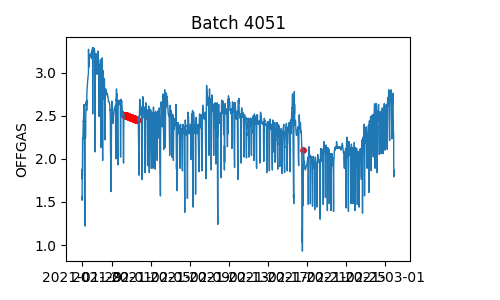

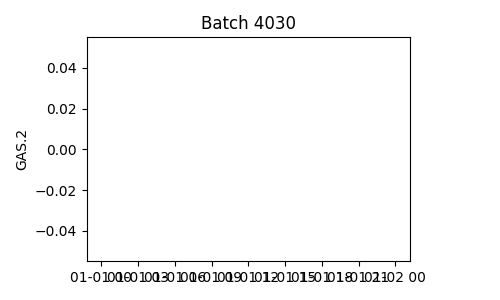

/var/folders/46/ddlt6_p52754jxg3fjz3_g2w0000gn/T/ipykernel_99269/4109869183.py:192: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows), sharex=False)


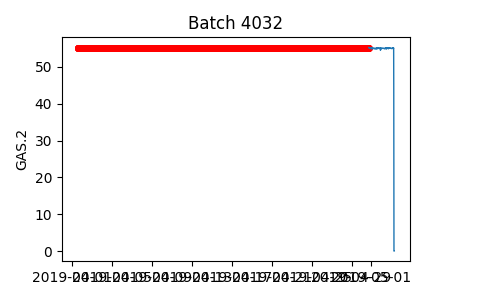

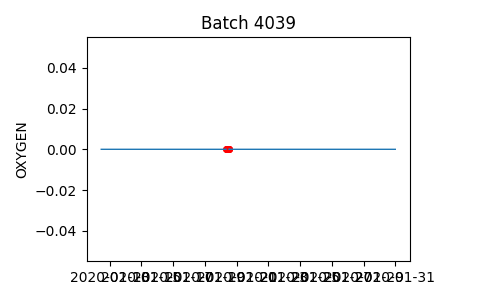

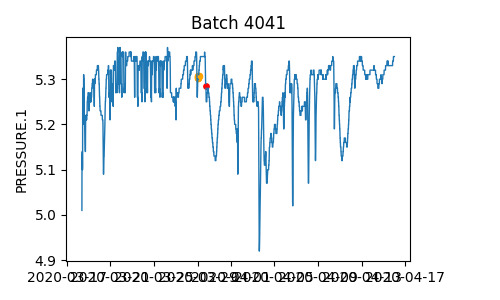

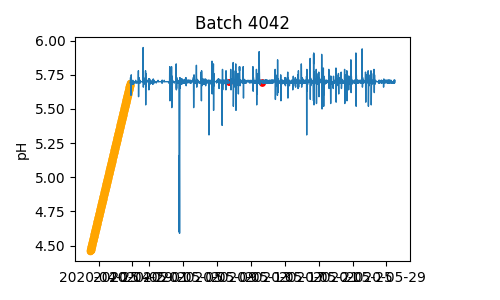

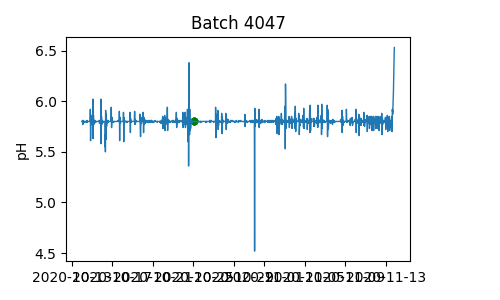

In [42]:
plotter.plot_batches_grid(batches=4051, columns=['OFFGAS'])
plotter.plot_batches_grid(batches=4030, columns=['GAS.2'])
plotter.plot_batches_grid(batches=4032, columns=['GAS.2'])
plotter.plot_batches_grid(batches=4039, columns='OXYGEN') 
plotter.plot_batches_grid(batches=4041, columns=['PRESSURE.1'])
plotter.plot_batches_grid(batches=4042, columns=['pH'])
plotter.plot_batches_grid(batches=4047, columns=['pH'])

In [43]:
def handle_nans(df, max_nans=20):
    df = df.copy()

    for col in df.columns:
        if col == "Date and time":
            continue

        df[col] = df[col].interpolate(
            method="linear",
            limit=max_nans,
            limit_area="inside"
        )

    return df

def handle_duplicate_timestamps(df, time_col="Date and time"):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col])

    # sort first
    df = df.sort_values(time_col)

    # separate numeric vs non-numeric
    numeric_cols = df.select_dtypes(include="number").columns.tolist()

    agg = {col: "mean" for col in numeric_cols}

    # override Batch if present
    if "Batch" in df.columns:
        agg["Batch"] = "first"

    # group duplicates
    df = (
        df.groupby(time_col, as_index=False)
          .agg(agg)
          .sort_values(time_col)
          .reset_index(drop=True)
    )

    return df

def insert_missing_timestamps(df, time_col="Date and time"):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.dropna(subset=[time_col]).sort_values(time_col)

    result = []

    for batch, group in df.groupby("Batch"):
        group = group.sort_values(time_col)

        # infer resolution from data
        diffs = group[time_col].diff().dropna()

        if len(diffs) == 0:
            continue

        # use most common timestep
        freq = diffs.mode().iloc[0]

        group = group.set_index(time_col)

        full_index = pd.date_range(
            start=group.index.min(),
            end=group.index.max(),
            freq=freq
        )

        new_index = group.index.union(full_index)
        group = group.reindex(new_index).sort_index()

        # preserve batch
        group["Batch"] = batch

        result.append(group)

    df = pd.concat(result).reset_index().rename(columns={"index": time_col})

    return df


clean_op_df = handle_duplicate_timestamps(op_df)

clean_op_df = insert_missing_timestamps(clean_op_df)

clean_op_df = handle_nans(clean_op_df)

In [44]:
inspector = BatchTimeSeriesInspector(clean_op_df)

summary_df = inspector.summary(only_missing=False)
clean_batches = inspector.batches_by_quality(clean=True)
unclean_batches = inspector.batches_by_quality(clean=False)

In [45]:
inspector.inspect_batch(clean_batches, include_nan_cols=False)

,Batch,start_time,end_time,duration,resolution,rows
2,4033,2019-05-26 17:16:00,2019-06-23 20:01:00,28 days 02:45:00,0 days 00:15:00,2700
3,4034,2019-07-02 13:01:00,2019-08-03 23:46:00,32 days 10:45:00,0 days 00:15:00,3116
4,4035,2019-08-12 17:46:00,2019-09-08 23:46:00,27 days 06:00:00,0 days 00:15:00,2617
5,4036,2019-09-18 12:16:00,2019-10-20 23:46:00,32 days 11:30:00,0 days 00:15:00,3119
6,4037,2019-10-29 04:01:00,2019-11-20 14:31:00,22 days 10:30:00,0 days 00:15:00,2155
7,4038,2019-12-01 01:01:00,2019-12-30 15:31:00,29 days 14:30:00,0 days 00:15:00,2843
8,4039,2020-01-12 11:16:00,2020-01-30 23:46:00,18 days 12:30:00,0 days 00:15:00,1779
9,4040,2020-02-08 11:31:00,2020-03-08 04:01:00,28 days 16:30:00,0 days 00:15:00,2755
10,4041,2020-03-18 09:31:00,2020-04-15 23:46:00,28 days 14:15:00,0 days 00:15:00,2746
12,4043,2020-06-09 19:16:00,2020-06-28 16:16:00,18 days 21:00:00,0 days 00:15:00,1813


In [46]:
plotter1 = BatchTimeSeriesPlotter(clean_op_df)

In [47]:
# plotter1.plot(batch=4032, width=5)

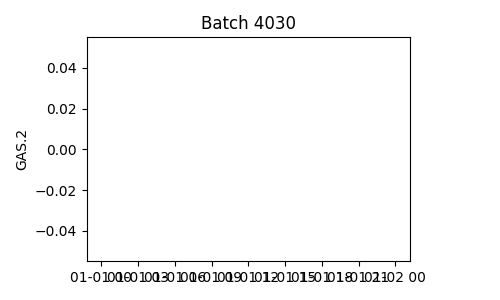

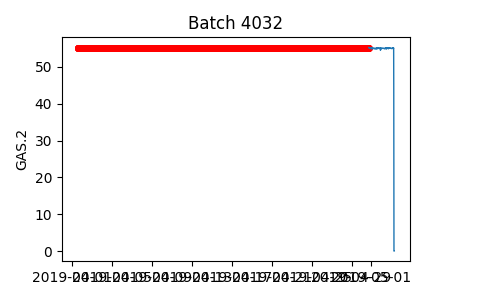

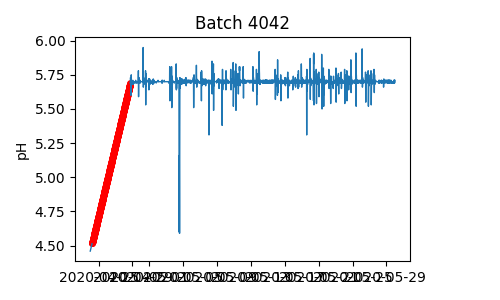

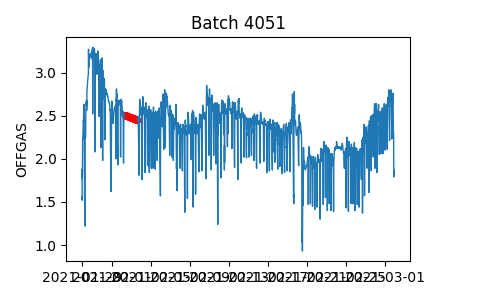

In [48]:
plotter1.plot_batches_grid(batches=4030, columns=['GAS.2'])
plotter1.plot_batches_grid(batches=4032, columns=['GAS.2'])
plotter1.plot_batches_grid(batches=4042, columns=['pH'])
plotter1.plot_batches_grid(batches=4051, columns=['OFFGAS'])


In [49]:
clean_op_df = clean_op_df[clean_op_df["Batch"].isin(clean_batches)]

NEED TO DO PRODUCTION DATA INPSECTION AND CLEANING 

### **Ranking productivity of batch Product Rate(Task2&3)**

Compute the **product rate** for each batch using the following formula:

$$
\text{Product Rate (kg/hr)} =
\text{mean product (g/L)} \times
\text{mean total liquid inflow rate (L/hr)} \times 0.001
$$

where the **total liquid inflow rate** is defined as:

$$
\text{Total liquid inflow} =
\sum_{i=1}^{6} \text{liquid inflow}_i
$$

Using the computed product rates, **rank the productivity of the batches**.  
The product rate is a valid comparison metric across batches and is **independent of batch duration**, which is highly variable.

In [50]:
##### ADD THE CLEAN, UNCLEAN TAG


import pandas as pd

def compute_batch_productivity(op_df, prod_df):

    liquid_cols = [
        "LIQUID", "LIQUID.1", "LIQUID.2",
        "LIQUID.3", "LIQUID.4", "LIQUID.5"
    ]

    op_df = op_df.copy()
    prod_df = prod_df.copy()

    # total liquid inflow per row
    op_df["total_liquid_inflow"] = op_df[liquid_cols].sum(axis=1, skipna=True)

    # batch means
    mean_liquid = (
        op_df.groupby("Batch")["total_liquid_inflow"]
        .mean()
        .rename("mean_total_liquid")
    )

    mean_product = (
        prod_df.groupby("Batch")["Product"]
        .mean()
        .rename("mean_product")
    )

    # combine
    batch_product_rate = pd.concat(
        [mean_product, mean_liquid],
        axis=1
    )

    # product rate
    batch_product_rate["product_rate_kg_hr"] = (
        batch_product_rate["mean_product"]
        * batch_product_rate["mean_total_liquid"]
        * 0.001
    )

    # rank batches by productivity
    batch_product_rate = (
        batch_product_rate
        .sort_values("product_rate_kg_hr", ascending=False)
        .assign(productivity_rank=lambda df: range(1, len(df) + 1))
    )

    return batch_product_rate

batch_product_rate = compute_batch_productivity(op_df, prod_df)
batch_product_rate

,mean_product,mean_total_liquid,product_rate_kg_hr,productivity_rank
Batch,,,,
4041,27.263270,24583.602688,670.229408,1
4043,27.041068,24753.736520,669.367477,2
4047,26.370833,25144.553486,663.082829,3
4040,26.450455,24623.509532,651.303020,4
4042,26.367835,24493.636569,645.844169,5
4046,26.017734,24782.597009,644.787017,6
4045,26.591552,24100.309285,640.864621,7
4052,25.787324,24405.554019,629.353928,8
4034,25.052205,24835.980215,622.196071,9


### **Feature Engineering**

TALK ABOUT IN PRESENTATION BRIEFLY AS FUTURE WORK

### **Identifying Process Drivers of Product Rate (Task4)**

Use **machine learning procedures** to identify the **process parameters most clearly related to product rate variability**.

The product rate is defined by the process equation

$$
\text{Product Rate (kg/hr)} =
\text{Mean Product (g/L)} \times
\text{Mean Total Liquid Inflow Rate (L/hr)} \times 0.001
$$

where the total inflow rate is

$$
\text{Total Liquid Inflow} =
\sum_{i=1}^{6} \text{Liquid Inflow}_i
$$

Since the mean total liquid inflow rate is directly measured, it is treated as a known quantity. The machine learning model therefore predicts the **mean product concentration** rather than the product rate itself.

The model learns

$$
\text{Mean Product} = f(\mathbf{x})
$$

where $\mathbf{x}$ represents the observed process features.

The predicted product rate is then computed using the process equation

$$
\widehat{\text{Product Rate}} =
\hat{P} \times
\text{Mean Total Liquid Inflow Rate} \times 0.001
$$

This approach enforces the known physical relationship, reduces the learning burden on the model, and ensures that changes in flow rate are correctly reflected in the predicted product rate.

Modeling Approaches for Predicting Product Formation

Two main modeling strategies can be used to predict product formation in batch processes.

---

1. Batch-Level (Static) Modeling

In batch-level modeling, the full time-series data for each batch is summarized into statistical features (e.g., mean, standard deviation, maximum, totals, trends). A model is then trained to predict the final product concentration directly from these summary features.

The model learns the mapping

$$
\text{Mean Product} = f(\mathbf{x})
$$

where $\mathbf{x}$ represents the vector of batch summary features derived from process measurements.

Once the mean product concentration is predicted, the product rate can be calculated using the known process relationship

$$
\text{Product Rate} =
\text{Mean Product} \times
\text{Mean Total Liquid Inflow Rate} \times 0.001
$$

This approach is often referred to as:

- **Batch-level modeling**
- **Static modeling**
- **Summary-feature modeling**

It is commonly used in industrial process analytics because it is simple, robust, and works well when datasets are relatively small.

---

2. Time-Series (Dynamic / Trajectory) Modeling

In time-series modeling, the full temporal trajectory of the process variables is used rather than summarizing the batch. The model predicts the product concentration at each time step.

The dynamic relationship can be expressed as

$$
P_t = f(P_{t-1}, X_t)
$$

where $P_t$ is the product concentration at time $t$ and $X_t$ represents the process measurements at that time.

The batch mean product concentration can then be computed as

$$
\text{Mean Product} =
\frac{1}{T}\sum_{t=1}^{T} P_t
$$

This approach is commonly referred to as:

- **Time-series modeling**
- **Trajectory modeling**
- **Dynamic modeling**
- **Sequence modeling**

Typical models used for this approach include:

- Recurrent Neural Networks (RNN)
- Long Short-Term Memory networks (LSTM)
- Temporal convolutional models
- State-space models

---

Comparison

| Approach | Data Representation | Typical Models |
|---|---|---|
| Batch-level modeling | Batch summary statistics | Linear models, Random Forest, Gradient Boosting |
| Time-series modeling | Full process trajectory | RNN, LSTM, temporal models |

---

Practical Considerations

Batch-level modeling is more commonly used in industrial applications because it:

- works well with small datasets
- avoids irregular time-sampling issues
- is easier to interpret
- requires less computational complexity

Time-series modeling is more appropriate when the goal is **real-time prediction during the batch**, such as soft sensing or process control.

#### **Batch-Level (Static) Modeling**

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [52]:
from applied.data_processing import build_features_and_target
from applied.models import correlation_report

X, y = build_features_and_target(op_df, prod_df)

In [53]:
X.columns

Index(['LIQUID_mean', 'LIQUID_std', 'LIQUID_max', 'LIQUID_min', 'LIQUID_sum',
       'LIQUID.1_mean', 'LIQUID.1_std', 'LIQUID.1_max', 'LIQUID.1_min',
       'LIQUID.1_sum', 'LIQUID.2_mean', 'LIQUID.2_std', 'LIQUID.2_max',
       'LIQUID.2_min', 'LIQUID.2_sum', 'LIQUID.3_mean', 'LIQUID.3_std',
       'LIQUID.3_max', 'LIQUID.3_min', 'LIQUID.3_sum', 'LIQUID.4_mean',
       'LIQUID.4_std', 'LIQUID.4_max', 'LIQUID.4_min', 'LIQUID.4_sum',
       'LIQUID.5_mean', 'LIQUID.5_std', 'LIQUID.5_max', 'LIQUID.5_min',
       'LIQUID.5_sum', 'GAS_mean', 'GAS_std', 'GAS_max', 'GAS_min', 'GAS_sum',
       'GAS.1_mean', 'GAS.1_std', 'GAS.1_max', 'GAS.1_min', 'GAS.1_sum',
       'GAS.2_mean', 'GAS.2_std', 'GAS.2_max', 'GAS.2_min', 'GAS.2_sum',
       'GAS.3_mean', 'GAS.3_std', 'GAS.3_max', 'GAS.3_min', 'GAS.3_sum',
       'pH_mean', 'pH_std', 'pH_max', 'pH_min', 'OFFGAS_mean', 'OFFGAS_std',
       'OFFGAS_max', 'OFFGAS_min', 'OFFGAS.1_mean', 'OFFGAS.1_std',
       'OFFGAS.1_max', 'OFFGAS.1_min', 'PRESSURE


===== Running RandomForest =====


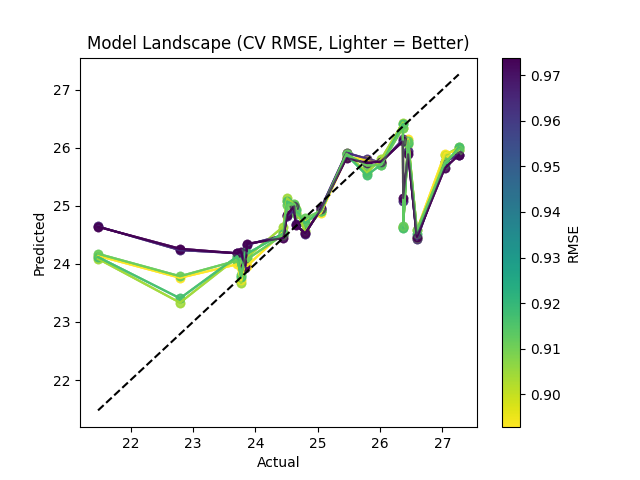


BEST:
RMSE: 0.8928139295437955
Params: {'model__n_estimators': 200, 'model__max_depth': None, 'model__min_samples_leaf': 2}

===== Running Lasso =====


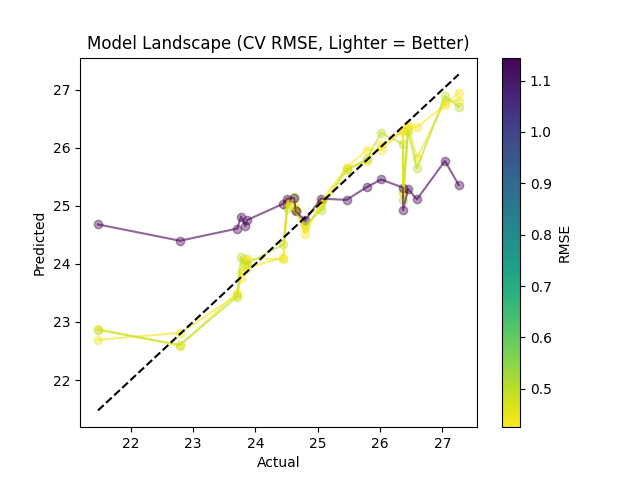


BEST:
RMSE: 0.42527680126975664
Params: {'model__alpha': 0.001}

===== Running GradientBoosting =====


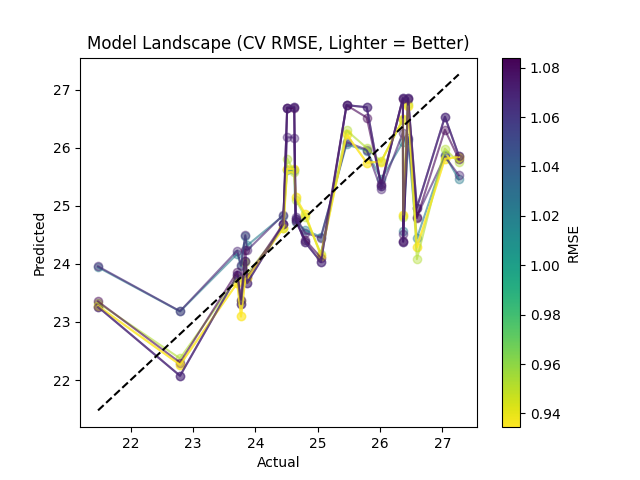


BEST:
RMSE: 0.9344140588533962
Params: {'model__n_estimators': 300, 'model__learning_rate': 0.1, 'model__max_depth': 3}

===== FINAL COMPARISON =====
RF: 0.8928139295437955
Lasso: 0.42527680126975664
GB: 0.9344140588533962


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from itertools import product
import matplotlib.cm as cm


# -------------------------
# MODEL FACTORIES
# -------------------------
def get_rf():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

def get_lasso():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),  # ✅ ADD THIS
        ("model", Lasso(max_iter=10000))  # ✅ increase iterations
    ])

def get_gboost():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(random_state=42))
    ])


# -------------------------
# EVALUATION (GENERIC FIX)
# -------------------------
def evaluate_all_models(X, y, param_grid, model_fn):
    results = []

    mask = ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for combo in product(*values):
        params = dict(zip(keys, combo))

        model = model_fn()
        model.set_params(**params)

        rmses = []
        oof_pred = np.zeros(len(y_clean))

        for train_idx, val_idx in kf.split(X_clean):

            X_train = X_clean.iloc[train_idx]
            X_val = X_clean.iloc[val_idx]

            y_train = y_clean.iloc[train_idx]
            y_val = y_clean.iloc[val_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            oof_pred[val_idx] = y_pred

            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            rmses.append(rmse)

        results.append({
            "params": params,
            "y_pred": oof_pred,
            "rmse": np.mean(rmses)
        })

    return results, y_clean


# -------------------------
# PLOTTING
# -------------------------
def plot_model_landscape(y_true, results):
    rmses = np.array([r["rmse"] for r in results])

    norm = plt.Normalize(vmin=rmses.min(), vmax=rmses.max())
    cmap = cm.viridis_r

    fig, ax = plt.subplots()
    y_true_np = np.asarray(y_true)

    for r in results:
        y_pred_np = np.asarray(r["y_pred"])

        sort_idx = np.argsort(y_true_np)
        x_sorted = y_true_np[sort_idx]
        y_sorted = y_pred_np[sort_idx]

        color = cmap(norm(r["rmse"]))

        ax.scatter(x_sorted, y_sorted, color=color, alpha=0.4)
        ax.plot(x_sorted, y_sorted, color=color, alpha=0.6)

    min_val = y_true_np.min()
    max_val = y_true_np.max()
    ax.plot([min_val, max_val], [min_val, max_val], 'k--')

    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title("Model Landscape (CV RMSE, Lighter = Better)")

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig.colorbar(sm, ax=ax, label="RMSE")
    plt.show()


# -------------------------
# PIPELINE WRAPPER
# -------------------------
def run_model_pipeline(X, y, param_grid, model_fn, name="model", plot=True):

    print(f"\n===== Running {name} =====")

    results, y_clean = evaluate_all_models(X, y, param_grid, model_fn)

    if plot:
        plot_model_landscape(y_clean, results)

    best = min(results, key=lambda r: r["rmse"])

    print("\nBEST:")
    print("RMSE:", best["rmse"])
    print("Params:", best["params"])

    # retrain on full data
    mask = ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]

    final_model = model_fn()
    final_model.set_params(**best["params"])
    final_model.fit(X_clean, y_clean)

    return {
        "model": final_model,
        "rmse": best["rmse"],
        "params": best["params"],
        "results": results
    }


# -------------------------
# PARAM GRIDS
# -------------------------
rf_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [5, 8, 12, None],
    "model__min_samples_leaf": [1, 2, 5],
}

lasso_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0]
}

gboost_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.01, 0.1],
    "model__max_depth": [3, 5]
}


# -------------------------
# RUN ALL MODELS
# -------------------------
rf_results = run_model_pipeline(X, y, rf_grid, get_rf, name="RandomForest")
lasso_results = run_model_pipeline(X, y, lasso_grid, get_lasso, name="Lasso")
gboost_results = run_model_pipeline(X, y, gboost_grid, get_gboost, name="GradientBoosting")


# -------------------------
# FINAL COMPARISON
# -------------------------
print("\n===== FINAL COMPARISON =====")
print("RF:", rf_results["rmse"])
print("Lasso:", lasso_results["rmse"])
print("GB:", gboost_results["rmse"])

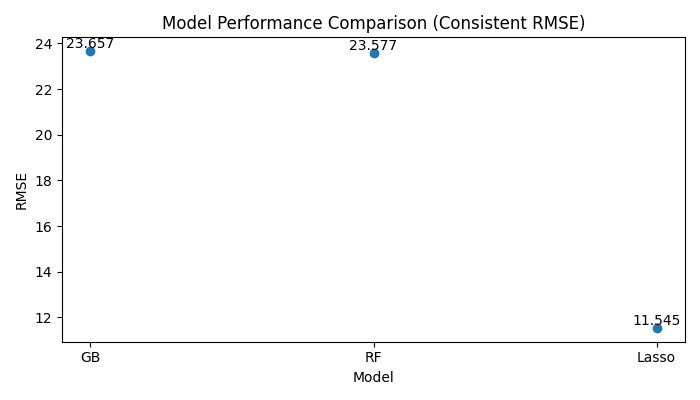

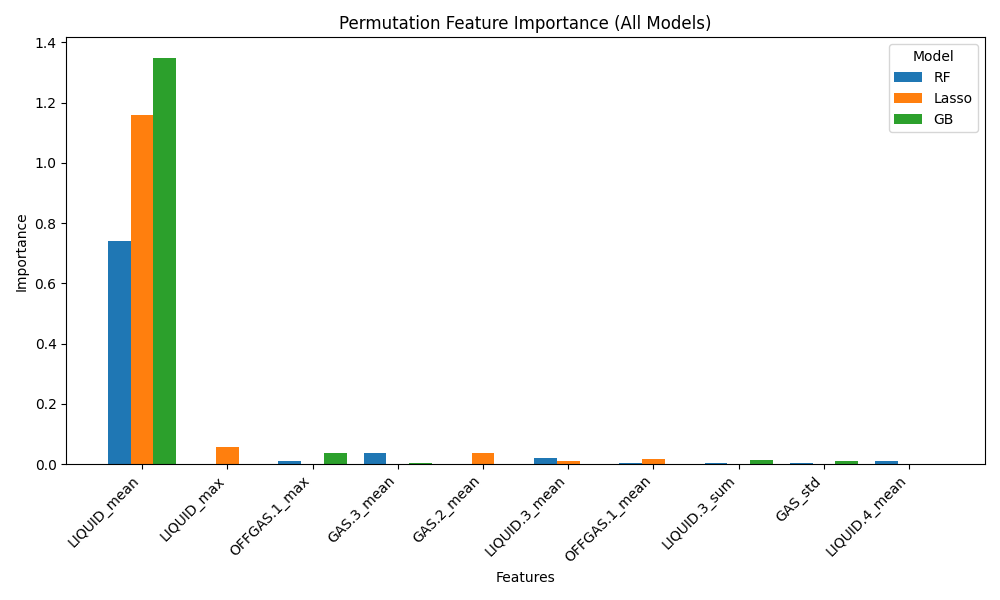

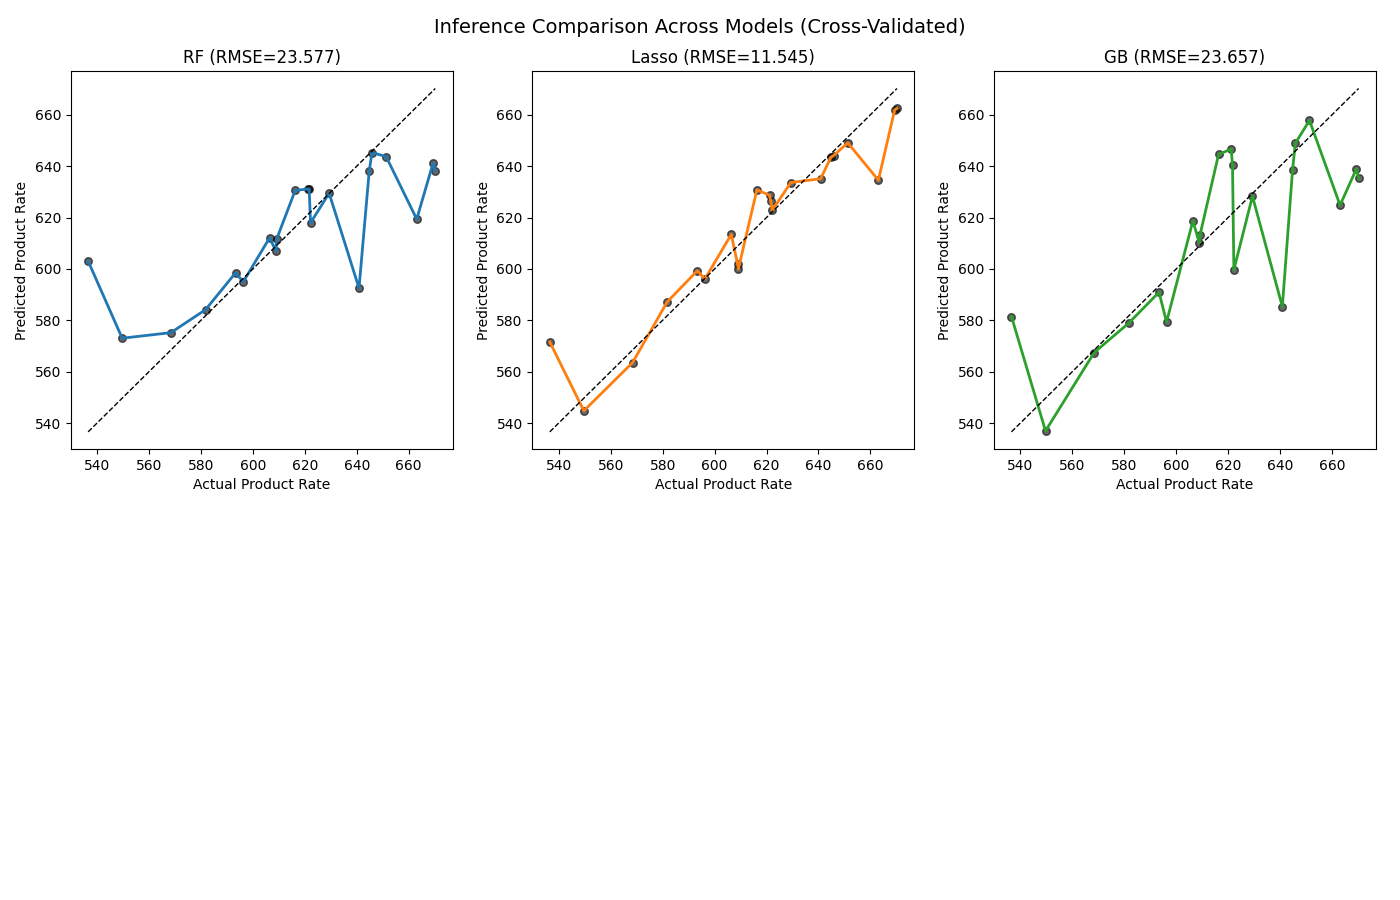

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_val_predict

def plot_model_rmse1(model_results_dict):
    """
    model_results_dict = {
        "RF": rf_results,
        "Lasso": lasso_results,
        ...
    }
    """

    names = []
    rmses = []

    for name, res in model_results_dict.items():
        names.append(name)
        rmses.append(res["rmse"])

    rmse_series = pd.Series(rmses, index=names).sort_values(ascending=False)

    plt.figure(figsize=(7, 4))
    plt.scatter(rmse_series.index, rmse_series.values)

    for i, v in enumerate(rmse_series.values):
        plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

    plt.ylabel("RMSE")
    plt.xlabel("Model")
    plt.title("Model Performance Comparison")

    plt.show()

from sklearn.model_selection import KFold, cross_val_predict

def plot_model_rmse(model_results_dict, X, y, inflow=None, n_splits=5):
    """
    Computes RMSE consistently using OOF predictions.
    Matches inference plot logic (supports rate if inflow provided).
    """

    mask = ~np.isnan(y)
    X_clean = X.loc[mask]
    y_clean = y.loc[mask]

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    rmse_dict = {}

    for name, res in model_results_dict.items():

        model = res["model"]

        # OOF predictions
        preds = cross_val_predict(
            model,
            X_clean,
            y_clean,
            cv=cv,
            n_jobs=-1
        )

        preds = pd.Series(preds, index=y_clean.index)

        # apply rate if needed
        if inflow is not None:
            inflow_clean = inflow.loc[X_clean.index]
            y_true = y_clean * inflow_clean * 0.001
            y_pred = preds * inflow_clean * 0.001
        else:
            y_true = y_clean
            y_pred = preds

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        rmse_dict[name] = rmse

    # convert to series
    rmse_series = pd.Series(rmse_dict).sort_values(ascending=False)

    # plot
    plt.figure(figsize=(7, 4))
    plt.scatter(rmse_series.index, rmse_series.values)

    for i, v in enumerate(rmse_series.values):
        plt.text(i, v, f"{v:.3f}", ha="center", va="bottom")

    plt.ylabel("RMSE")
    plt.xlabel("Model")
    plt.title("Model Performance Comparison (Consistent RMSE)")

    plt.tight_layout()
    plt.show()

def compute_permutation_importance(model, X, y, n_repeats=20):
    mask = ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]

    perm = permutation_importance(
        model,
        X_clean,
        y_clean,
        n_repeats=n_repeats,
        random_state=42,
        n_jobs=-1
    )

    importance = pd.Series(
        perm.importances_mean,
        index=X_clean.columns
    ).sort_values(ascending=False)

    return importance

def plot_permutation_importance(importance_dict, top_n=10):
    """
    importance_dict = {
        "RF": pd.Series,
        "Lasso": pd.Series,
        ...
    }
    """

    # combine into DataFrame
    df = pd.DataFrame(importance_dict)

    # select top features (by average importance)
    top_features = (
        df.mean(axis=1)
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    df = df.loc[top_features]

    # --- grouped bar plot ---
    models = df.columns
    features = df.index

    n_models = len(models)
    x = np.arange(len(features))
    width = 0.8 / n_models

    plt.figure(figsize=(10, 6))

    for i, model in enumerate(models):
        plt.bar(
            x + i * width,
            df[model],
            width=width,
            label=model
        )

    plt.xticks(
        x + width * (n_models - 1) / 2,
        features,
        rotation=45,
        ha="right"
    )

    plt.title("Permutation Feature Importance (All Models)")
    plt.ylabel("Importance")
    plt.xlabel("Features")

    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

def plot_inference_comparison(model_results_dict, X, y, inflow=None, n_splits=5):

    mask = ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    # rate transform (optional)
    if inflow is not None:
        inflow = inflow.loc[X_clean.index]
        y_true = y_clean * inflow * 0.001
        y_label = "Product Rate"
    else:
        y_true = y_clean
        y_label = "Target"

    model_names = list(model_results_dict.keys())
    n_models = len(model_names)

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    lims = [y_true.min(), y_true.max()]

    for i, (name, res) in enumerate(model_results_dict.items()):

        ax = axes[i]
        color = colors[i]

        model = res["model"]

        # OOF predictions
        preds = cross_val_predict(
            model,
            X_clean,
            y_clean,
            cv=cv,
            n_jobs=-1
        )

        if inflow is not None:
            preds = pd.Series(preds, index=y_clean.index)
            y_pred = preds * inflow * 0.001
        else:
            y_pred = preds

        df = pd.DataFrame({
            "true": y_true,
            "pred": y_pred
        }).sort_values("true")

        # scatter
        ax.scatter(
            df["true"],
            df["pred"],
            color="black",
            alpha=0.6,
            s=30
        )

        # line
        ax.plot(
            df["true"],
            df["pred"],
            color=color,
            linewidth=2
        )

        # perfect line
        ax.plot(lims, lims, "k--", linewidth=1)

        rmse = np.sqrt(mean_squared_error(df["true"], df["pred"]))
        ax.set_title(f"{name} (RMSE={rmse:.3f})")

        ax.set_xlabel(f"Actual {y_label}")
        ax.set_ylabel(f"Predicted {y_label}")

    # remove empty plots
    for j in range(n_models, 6):
        fig.delaxes(axes[j])

    plt.suptitle("Inference Comparison Across Models (Cross-Validated)", fontsize=14)
    plt.tight_layout()
    plt.show()


model_results = {
    "RF": rf_results,
    "Lasso": lasso_results,
    "GB": gboost_results
}

# compute inflow per batch
liquid_cols = [
    "LIQUID","LIQUID.1","LIQUID.2",
    "LIQUID.3","LIQUID.4","LIQUID.5"
]

op_df["total_liquid"] = op_df[liquid_cols].sum(axis=1)

inflow = op_df.groupby("Batch")["total_liquid"].mean()

# map inflow to X
inflow_series = pd.Series(X.index.map(inflow), index=X.index)

# Compare models
plot_model_rmse(
    model_results,
    X,
    y,
    inflow=inflow_series   # 🔥 must match inference
)

# Permutation importance (example: RF)
rf_importance = compute_permutation_importance(rf_results["model"], X, y)
lasso_importance = compute_permutation_importance(lasso_results["model"], X, y)
gboost_importance = compute_permutation_importance(gboost_results["model"], X, y)

# combine
importance_dict = {
    "RF": rf_importance,
    "Lasso": lasso_importance,
    "GB": gboost_importance
}

# plot
plot_permutation_importance(importance_dict, top_n=10)

# run plot
plot_inference_comparison(
    model_results,
    X,
    y,
    inflow=inflow_series
)

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error


class ModelEvaluator:

    def __init__(self, op_df, n_splits=5, random_state=42):

        self.random_state = random_state
        self.op_df = op_df

        self.cv = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        # liquid columns used to compute total inflow
        self.liquid_cols = [
            "LIQUID","LIQUID.1","LIQUID.2",
            "LIQUID.3","LIQUID.4","LIQUID.5"
        ]

        # compute batch mean total inflow
        self.inflow = self._compute_mean_total_liquid_inflow()

        self.models = {

            "Ridge": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0)),
            ]),

            "Lasso": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Lasso(alpha=0.01, max_iter=10000)),
            ]),

            "ElasticNet": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
            ]),

            "RandomForest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(
                    n_estimators=800,
                    min_samples_leaf=5,
                    random_state=random_state,
                    n_jobs=-1
                )),
            ]),

            "HistGradientBoosting": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    random_state=random_state
                )),
            ]),
        }

        self.results = None
        self.importance_df = None


    def _compute_mean_total_liquid_inflow(self):
        """Compute batch mean total liquid inflow."""
        df = self.op_df.copy()

        df["total_liquid"] = df[self.liquid_cols].sum(axis=1)

        inflow = (
            df.groupby("Batch")["total_liquid"]
            .mean()
        )

        return inflow


    def evaluate(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        inflow = self.inflow.loc[X.index]

        results = {}

        for name, model in self.models.items():

            rmses = []

            for train_idx, test_idx in self.cv.split(X):

                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                inflow_test = inflow.iloc[test_idx]

                model.fit(X_train, y_train)

                mean_pred = model.predict(X_test)

                rate_pred = mean_pred * inflow_test * 0.001
                rate_true = y_test * inflow_test * 0.001

                rmse = np.sqrt(mean_squared_error(rate_true, rate_pred))
                rmses.append(rmse)

            results[name] = np.mean(rmses)
            print(f"{name}: RMSE (Product Rate) = {results[name]:.4f}")

        self.results = results
        return results


    def plot_model_rmse(self):

        if self.results is None:
            raise ValueError("Run evaluate() first.")

        rmse_series = pd.Series(self.results).sort_values(ascending=False)

        plt.figure(figsize=(7,4))

        plt.scatter(rmse_series.index, rmse_series.values)

        for i, v in enumerate(rmse_series.values):
            plt.text(i, v + 0.2, f"{v:.2f}", ha="center")

        plt.ylabel("RMSE (Product Rate)")
        plt.xlabel("Model")
        plt.title("Model Performance Ranking")

        plt.show()


    def compute_permutation_importance(self, X, y, n_repeats=20):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        importance_dict = {}

        for name, model in self.models.items():

            model.fit(X, y)

            perm = permutation_importance(
                model,
                X,
                y,
                n_repeats=n_repeats,
                random_state=self.random_state,
                n_jobs=-1
            )

            importance = pd.Series(
                perm.importances_mean,
                index=X.columns
            )

            importance_dict[name] = importance

        self.importance_df = pd.DataFrame(importance_dict)

        return self.importance_df


    def plot_permutation_importance(self, top_n=10):

        if self.importance_df is None:
            raise ValueError("Run compute_permutation_importance() first.")

        importance_df = self.importance_df.copy()

        top_features = (
            importance_df.mean(axis=1)
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )

        data = importance_df.loc[top_features]

        data.plot(kind="bar", figsize=(10,6))

        plt.title("Permutation Feature Importance Comparison")
        plt.ylabel("Importance")
        plt.xlabel("Features")

        plt.xticks(rotation=45)
        plt.legend(title="Model")

        plt.tight_layout()
        plt.show()


    def plot_inference_comparison1(self, X, y):

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        inflow = self.inflow.loc[X.index]
        rate_true = y * inflow * 0.001

        model_names = list(self.models.keys())
        n_models = len(model_names)

        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        axes = axes.flatten()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        lims = [rate_true.min(), rate_true.max()]

        for i, (name, model) in enumerate(self.models.items()):

            ax = axes[i]
            color = colors[i]

            model.fit(X, y)

            mean_pred = model.predict(X)
            rate_pred = mean_pred * inflow * 0.001

            df = pd.DataFrame({
                "true": rate_true,
                "pred": rate_pred
            }).sort_values("true")

            # actual points
            ax.scatter(
                df["true"],
                df["pred"],
                color="black",
                alpha=0.5,
                s=30
            )

            # model prediction line
            ax.plot(
                df["true"],
                df["pred"],
                color=color,
                linewidth=2,
                label=name
            )

            # perfect prediction line
            ax.plot(lims, lims, "k--", linewidth=1)

            ax.set_title(name)
            ax.set_xlabel("Actual Product Rate")
            ax.set_ylabel("Predicted Product Rate")

        # remove unused subplot (since 5 models)
        for j in range(n_models, 6):
            fig.delaxes(axes[j])

        plt.suptitle("Inference Comparison Across Models", fontsize=14)
        plt.tight_layout()
        plt.show()


    def plot_inference_comparison(self, X, y):

        from sklearn.model_selection import cross_val_predict

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]

        inflow = self.inflow.loc[X.index]
        rate_true = y * inflow * 0.001

        model_names = list(self.models.keys())
        n_models = len(model_names)

        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        axes = axes.flatten()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        lims = [rate_true.min(), rate_true.max()]

        for i, (name, model) in enumerate(self.models.items()):

            ax = axes[i]
            color = colors[i]

            # out-of-fold predictions
            mean_pred = cross_val_predict(
                model,
                X,
                y,
                cv=self.cv,
                n_jobs=-1
            )

            rate_pred = mean_pred * inflow * 0.001

            df = pd.DataFrame({
                "true": rate_true,
                "pred": rate_pred
            }).sort_values("true")

            # predicted points
            ax.scatter(
                df["true"],
                df["pred"],
                color="black",
                alpha=0.6,
                s=30
            )

            # smooth trend line
            ax.plot(
                df["true"],
                df["pred"],
                color=color,
                linewidth=2,
                label=name
            )

            # perfect prediction line
            ax.plot(lims, lims, "k--", linewidth=1)

            ax.set_title(name)
            ax.set_xlabel("Actual Product Rate")
            ax.set_ylabel("Predicted Product Rate")

        # remove unused subplot
        for j in range(n_models, 6):
            fig.delaxes(axes[j])

        plt.suptitle("Inference Comparison Across Models (Cross-Validated)", fontsize=14)
        plt.tight_layout()
        plt.show()

Ridge: RMSE (Product Rate) = 37.8945
Lasso: RMSE (Product Rate) = 10.9279
ElasticNet: RMSE (Product Rate) = 14.6602
RandomForest: RMSE (Product Rate) = 24.0416
HistGradientBoosting: RMSE (Product Rate) = 36.0097


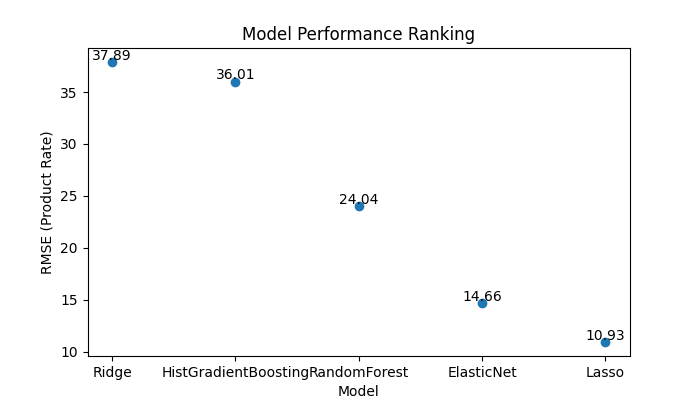

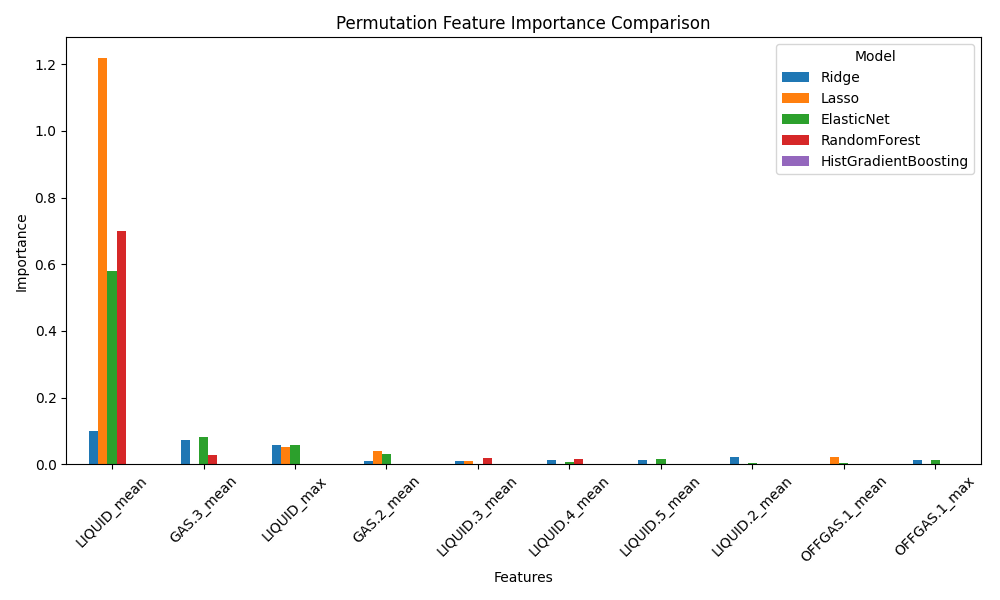

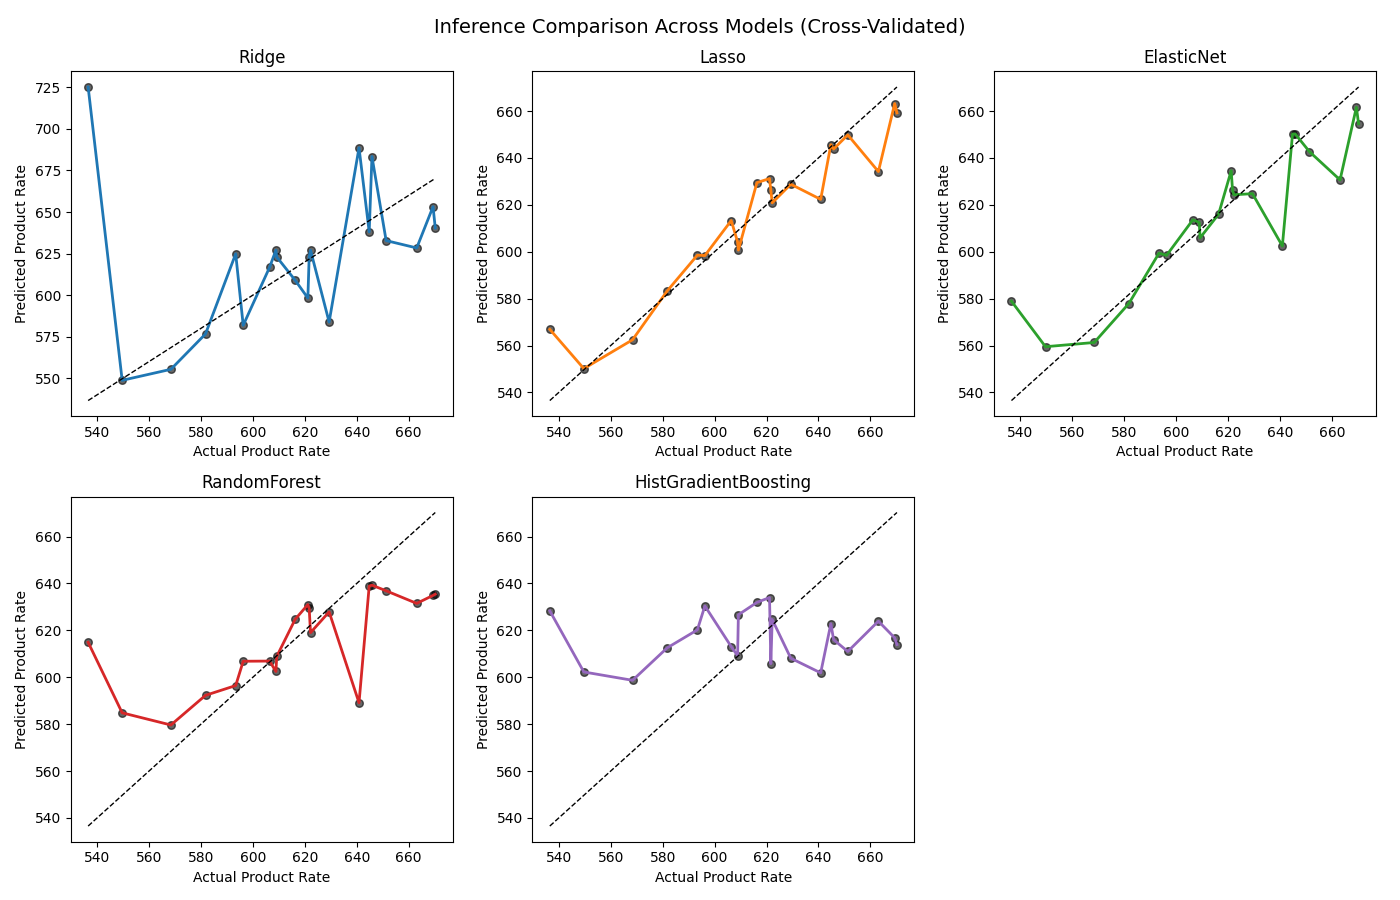

In [60]:
evaluator = ModelEvaluator(op_df)

evaluator.evaluate(X, y)

evaluator.plot_model_rmse()

evaluator.compute_permutation_importance(X, y)

evaluator.plot_permutation_importance(top_n=10)

evaluator.plot_inference_comparison(X, y)

In [51]:
feature_corr = correlation_report(X, threshold=0.8, mode="feature")
target_corr = correlation_report(X, y, threshold=0.7, mode="target")
features = target_corr["Feature"].tolist()

print(feature_corr, '\n\n', target_corr)

       Feature_1       Feature_2  Correlation
0   LIQUID.2_min    LIQUID.4_min     0.999997
1   LIQUID.1_sum    LIQUID.4_sum     0.999904
2   LIQUID.1_min    LIQUID.4_min     0.999902
3   LIQUID.1_min    LIQUID.2_min     0.999865
4   LIQUID.2_sum    LIQUID.4_sum     0.999660
..           ...             ...          ...
84  LIQUID.2_std  PRESSURE.1_std     0.821345
85    GAS.2_mean       GAS.2_std     0.815736
86  LIQUID.1_std  PRESSURE.1_std     0.812375
87  LIQUID.4_std    PRESSURE_std     0.806238
88     GAS.3_std          pH_std     0.804199

[89 rows x 3 columns] 

        Feature  Correlation_with_Target
0  LIQUID_mean                 0.949425
1   GAS.3_mean                 0.831788


#### **Time-Series (Dynamic / Trajectory) Modeling**

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance


class ModelEvaluator:

    def __init__(self, data, n_splits=5, random_state=42):

        self.data = data
        self.random_state = random_state

        # batch-aware CV
        self.cv = GroupKFold(n_splits=n_splits)

        # liquid columns
        self.liquid_cols = [
            "LIQUID","LIQUID.1","LIQUID.2",
            "LIQUID.3","LIQUID.4","LIQUID.5"
        ]

        self.models = {

            "Ridge": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Ridge(alpha=1.0))
            ]),

            "Lasso": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", Lasso(alpha=0.01, max_iter=10000))
            ]),

            "ElasticNet": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000))
            ]),

            "RandomForest": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=5,
                    random_state=random_state,
                    n_jobs=-1
                ))
            ]),

            "HistGradientBoosting": Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=500,
                    learning_rate=0.05,
                    random_state=random_state
                ))
            ]),
        }

        self.results = None
        self.importance_df = None


    def _compute_total_liquid(self, X):

        return X[self.liquid_cols].sum(axis=1)


    def evaluate(self, X, y, groups):

        results = {}

        for name, model in self.models.items():

            rmses = []

            for train_idx, test_idx in self.cv.split(X, y, groups):

                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
                batch_test = groups.iloc[test_idx]

                model.fit(X_train, y_train)

                pred = model.predict(X_test)

                total_liquid = self._compute_total_liquid(X_test)

                rate_pred = pred * total_liquid * 0.001
                rate_true = y_test * total_liquid * 0.001

                df = pd.DataFrame({
                    "Batch": batch_test,
                    "rate_true": rate_true,
                    "rate_pred": rate_pred
                })

                batch_df = df.groupby("Batch").mean()

                rmse = np.sqrt(
                    mean_squared_error(
                        batch_df["rate_true"],
                        batch_df["rate_pred"]
                    )
                )

                rmses.append(rmse)

            results[name] = np.mean(rmses)

            print(f"{name}: RMSE (Product Rate) = {results[name]:.4f}")

        self.results = results
        return results


    def plot_model_rmse(self):

        if self.results is None:
            raise ValueError("Run evaluate() first.")

        rmse_series = pd.Series(self.results).sort_values(ascending=False)

        plt.figure(figsize=(7,4))

        plt.scatter(rmse_series.index, rmse_series.values)

        for i, v in enumerate(rmse_series.values):
            plt.text(i, v + 0.2, f"{v:.2f}", ha="center")

        plt.ylabel("RMSE (Product Rate kg/hr)")
        plt.title("Model Performance Ranking")

        plt.show()


    def compute_permutation_importance(self, X, y):

        importance_dict = {}

        for name, model in self.models.items():

            model.fit(X, y)

            perm = permutation_importance(
                model,
                X,
                y,
                n_repeats=20,
                random_state=self.random_state,
                n_jobs=-1
            )

            importance_dict[name] = pd.Series(
                perm.importances_mean,
                index=X.columns
            )

        self.importance_df = pd.DataFrame(importance_dict)

        return self.importance_df


    def plot_permutation_importance(self, top_n=10):

        top_features = (
            self.importance_df.mean(axis=1)
            .sort_values(ascending=False)
            .head(top_n)
            .index
        )

        data = self.importance_df.loc[top_features]

        data.plot(kind="bar", figsize=(10,6))

        plt.title("Permutation Feature Importance")
        plt.ylabel("Importance")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()


    def plot_inference_comparison(self, X, y, groups):

        from sklearn.model_selection import cross_val_predict

        mask = ~np.isnan(y)
        X = X[mask]
        y = y[mask]
        groups = groups[mask]

        inflow = self._compute_total_liquid(X)
        rate_true = y * inflow * 0.001

        model_names = list(self.models.keys())
        n_models = len(model_names)

        fig, axes = plt.subplots(2, 3, figsize=(14, 9))
        axes = axes.flatten()

        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for i, (name, model) in enumerate(self.models.items()):

            ax = axes[i]
            color = colors[i]

            mean_pred = cross_val_predict(
                model,
                X,
                y,
                cv=self.cv,
                groups=groups,
                n_jobs=-1
            )

            rate_pred = mean_pred * inflow * 0.001

            df_plot = pd.DataFrame({
                "Batch": groups,
                "true": rate_true,
                "pred": rate_pred
            })

            # aggregate to batch level
            batch_df = df_plot.groupby("Batch", as_index=False).mean()
            batch_df = batch_df.sort_values("true")

            lims = [
                min(batch_df["true"].min(), batch_df["pred"].min()),
                max(batch_df["true"].max(), batch_df["pred"].max())
            ]

            ax.scatter(
                batch_df["true"],
                batch_df["pred"],
                color="black",
                alpha=0.7,
                s=40
            )

            ax.plot(
                batch_df["true"],
                batch_df["pred"],
                color=color,
                linewidth=2,
                label=name
            )

            ax.plot(lims, lims, "k--", linewidth=1)

            ax.set_title(name)
            ax.set_xlabel("Actual Product Rate")
            ax.set_ylabel("Predicted Product Rate")
            ax.set_xlim(lims)
            ax.set_ylim(lims)

        for j in range(n_models, 6):
            fig.delaxes(axes[j])

        plt.suptitle("Inference Comparison Across Models (Batch-Averaged CV)", fontsize=14)
        plt.tight_layout()
        plt.show()

In [53]:
def add_lags(df):

    # ensure correct temporal order
    df = df.sort_values(['Batch', 'Date and time']).copy()

    lag4_cols = [c for c in df.columns if c.startswith('LIQUID') or c.startswith('GAS')]
    lag2_cols = ['pH', 'OFFGAS', 'OFFGAS.1', 'PRESSURE', 'PRESSURE.1', 'OXYGEN']

    g = df.groupby('Batch')

    lag_frames = []

    for lag in range(1, 5):
        lag_df = g[lag4_cols].shift(lag)
        lag_df.columns = [f"{c}_lag{lag}" for c in lag_df.columns]
        lag_frames.append(lag_df)

    for lag in range(1, 3):
        lag_df = g[lag2_cols].shift(lag)
        lag_df.columns = [f"{c}_lag{lag}" for c in lag_df.columns]
        lag_frames.append(lag_df)

    return pd.concat([df] + lag_frames, axis=1)

def add_product_to_operating(op_df, prod_df):

    op_df = op_df.sort_values('Date and time').copy()
    prod_df  = prod_df.sort_values('Date and time')

    op_df = pd.merge_asof(
        op_df,
        prod_df[['Date and time', 'Product']],
        on='Date and time',
        direction='nearest',
        tolerance=pd.Timedelta('5min')
    )

    return op_df


op_df = add_lags(op_df)

data = add_product_to_operating(op_df, prod_df)

df_model = (
    data.dropna(subset=['Product'])
        .dropna()
        .drop(columns=['Date and time'])
        .reset_index(drop=True)
)

ValueError: Merge keys contain null values on left side

In [ ]:
groups = df_model.loc[df_model.index, "Batch"]

X = df_model.drop(columns=['Product'])
y = df_model['Product']

In [ ]:
groups.nunique()

20

In [ ]:
X, 

,Batch,LIQUID,LIQUID.1,LIQUID.2,LIQUID.3,LIQUID.4,LIQUID.5,pH,GAS,GAS.1,...,OFFGAS.1_lag1,PRESSURE_lag1,PRESSURE.1_lag1,OXYGEN_lag1,pH_lag2,OFFGAS_lag2,OFFGAS.1_lag2,PRESSURE_lag2,PRESSURE.1_lag2,OXYGEN_lag2
0,4032,1050.13,29.17,16.05,35.97,415.77,23910.0,5.74,7999.99,55.02,...,2.61,1.8,5.02,36.08,5.74,3.46,2.69,1.8,5.01,36.80
1,4032,1049.26,29.07,15.96,36.02,415.15,23900.0,5.74,8001.19,54.97,...,2.60,1.8,4.99,40.81,5.74,3.47,2.61,1.8,4.99,39.73
2,4032,1049.04,29.03,16.05,36.01,414.81,23910.0,5.74,7990.58,55.05,...,2.46,1.8,4.95,42.42,5.74,3.43,2.48,1.8,4.96,41.40
3,4032,1079.23,28.92,15.97,36.00,414.52,23900.0,5.74,7959.87,54.90,...,2.48,1.8,4.97,37.25,5.75,3.41,2.49,1.8,4.97,37.22
4,4032,1079.49,28.99,16.08,36.01,414.96,23890.0,5.75,7443.97,55.01,...,2.41,1.8,5.02,19.10,5.75,3.81,2.42,1.8,5.01,20.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756,4052,1219.05,36.02,19.72,47.02,517.70,22340.0,5.81,11012.67,55.06,...,4.65,2.0,5.28,3.90,5.82,2.59,4.66,2.0,5.28,5.25
3757,4052,1220.96,36.53,19.42,47.03,517.25,22300.0,5.80,11000.90,54.99,...,4.66,2.0,5.28,4.79,5.80,2.61,4.65,2.0,5.28,3.90
3758,4052,1220.49,37.16,19.72,47.00,517.26,22370.0,5.80,11002.10,54.84,...,4.66,2.0,5.31,2.22,5.79,2.55,4.66,2.0,5.32,2.21
3759,4052,1220.09,36.41,19.54,47.03,516.74,22350.0,5.80,11008.49,55.03,...,4.69,2.0,5.31,2.32,5.79,2.55,4.66,2.0,5.31,2.22


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Ridge: RMSE (Product Rate) = 23.5585
Lasso: RMSE (Product Rate) = 23.3615
ElasticNet: RMSE (Product Rate) = 22.3191
RandomForest: RMSE (Product Rate) = 17.3442
HistGradientBoosting: RMSE (Product Rate) = 18.4286


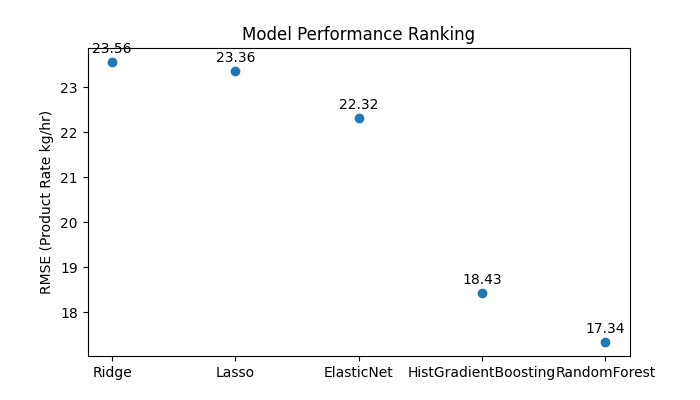

In [ ]:
evaluator = ModelEvaluator(data)

evaluator.evaluate(X, y, groups)

evaluator.plot_model_rmse()

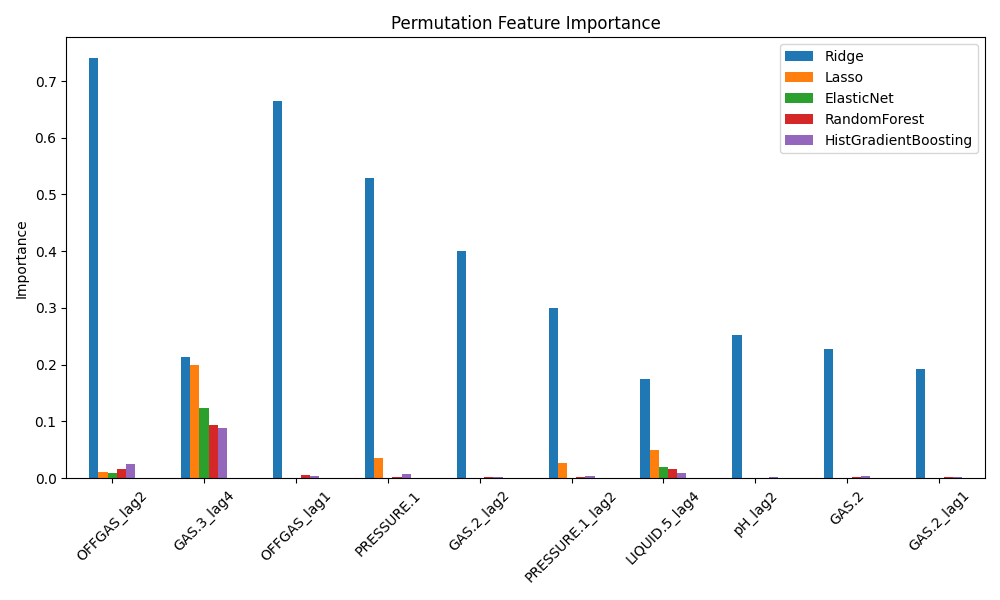

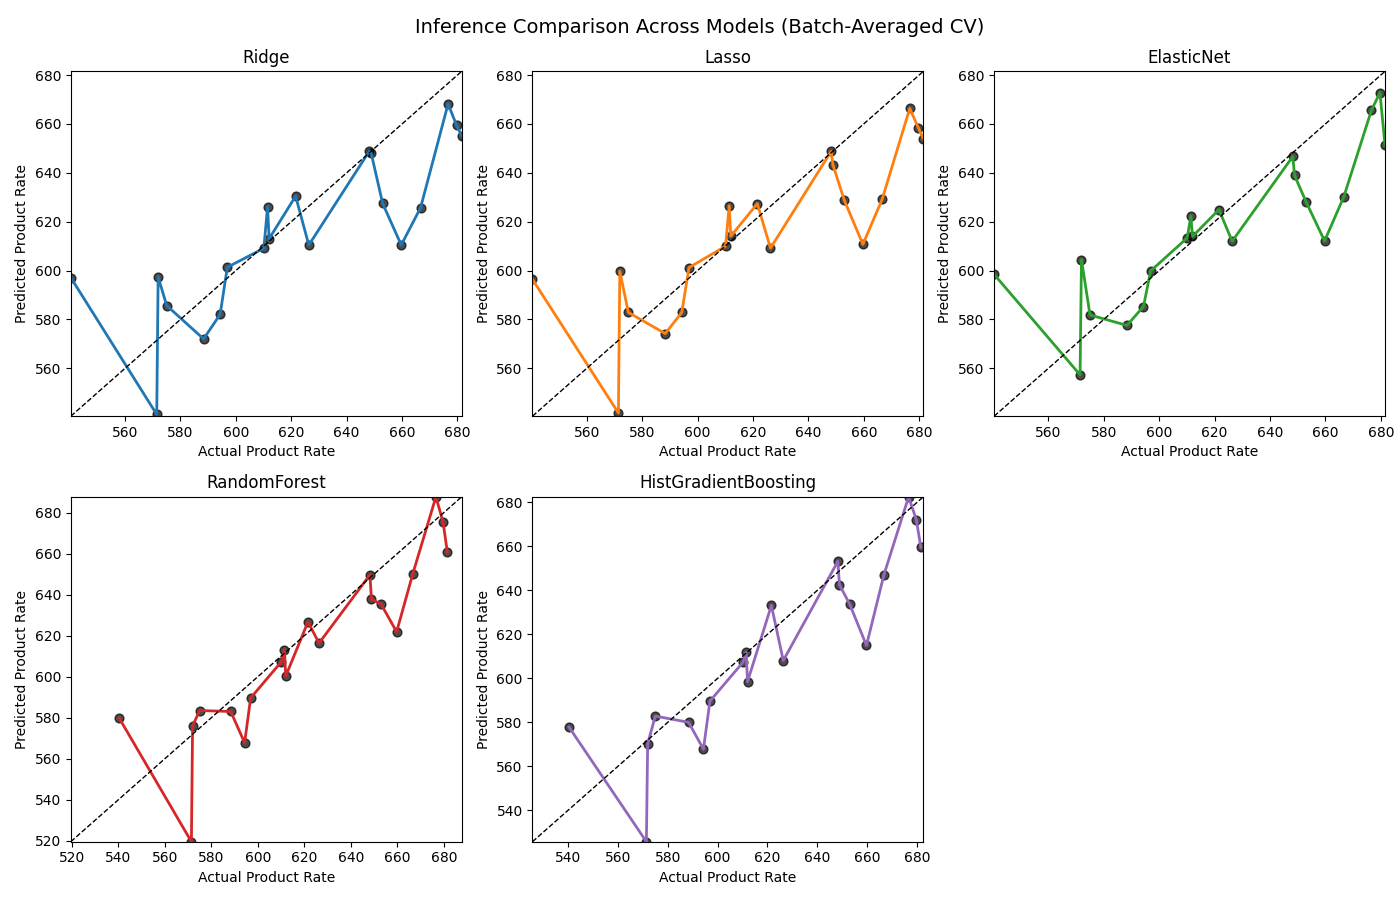

In [36]:
evaluator.compute_permutation_importance(X, y)

evaluator.plot_permutation_importance(top_n=10)

evaluator.plot_inference_comparison(X, y, groups)

### **Constructing a Predictive Model (Task5)**

Construct a **mathematical and/or computational model** that incorporates the insights from **Task 4** into a **predictive framework**.

Predictive Model Construction

Based on the feature importance analysis in Task 4, a reduced predictive framework was constructed using the most influential process parameters.

A Random Forest regressor was selected due to its superior cross-validated performance and ability to model non-linear interactions between process variables.

Predictive form:

y_hat = f(P, G_in, G_off, O2, L_in, pH)

where f(.) is a non-linear ensemble mapping learned via bootstrap aggregation of decision trees.

Cross-validation was used to estimate generalisation performance.

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Reduced feature set from Task 4
X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

# Predictive framework
framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse = -cross_val_score(
    framework,
    X_reduced,
    y_target,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

print(f"Cross-validated RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

Cross-validated RMSE: 14.197 ± 5.504


Train/test split + performance metrics

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
import numpy as np

X_reduced = X_clean[features].copy()
y_target = y_clean.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_target, test_size=0.2, random_state=42
)

framework = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)),
])

framework.fit(X_train, y_train)
y_pred = framework.predict(X_test)

# RMSE compatible with older sklearn:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE:  {mae:.3f}")
print(f"Test R²:   {r2:.3f}")

Test RMSE: 7.735
Test MAE:  6.864
Test R²:   0.872


Predicted Vs Actual

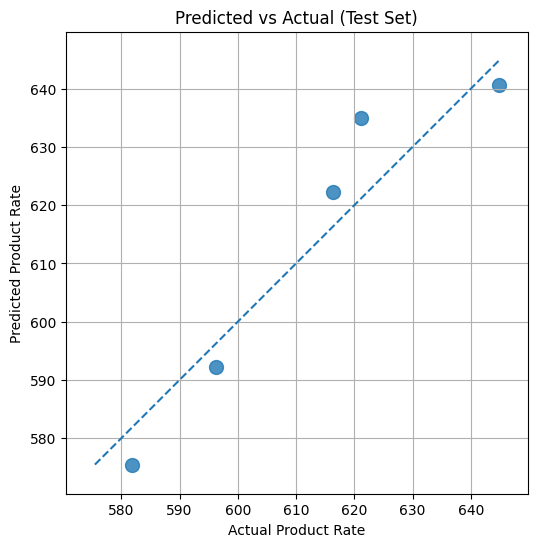

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, s=100, alpha=0.8)

# Perfect prediction line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Product Rate")
plt.ylabel("Predicted Product Rate")
plt.title("Predicted vs Actual (Test Set)")
plt.grid(True)

plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

The predicted versus actual plot demonstrates reasonable alignment with the 1:1 reference line, indicating that the Random Forest model captures a substantial proportion of productivity variability across batches. Most predictions lie close to the ideal line, although the highest productivity batch is moderately underpredicted, suggesting mild regression toward the mean. This behaviour is typical of ensemble tree models trained on relatively small datasets. Overall, the model exhibits stable generalisation performance without evidence of systematic bias.

Residuals Vs Pred

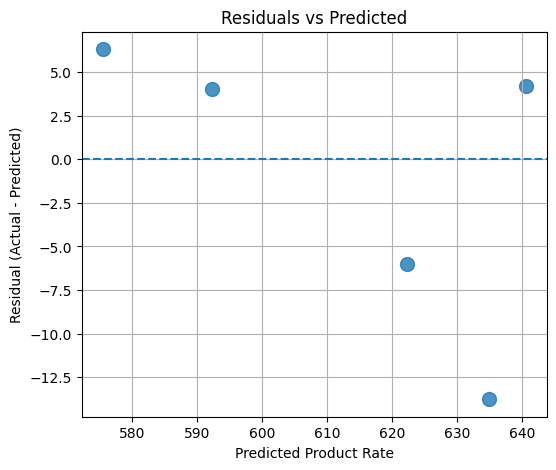

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, s=100, alpha=0.8)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Product Rate")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.grid(True)

plt.show()

Residuals are distributed around zero without clear structural pattern, indicating that the model does not exhibit strong systematic bias across the prediction range.

In [30]:
import pandas as pd

pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse, mae, r2]
})

,Metric,Value
0,RMSE,7.735395
1,MAE,6.863963
2,R²,0.872102


### **Predicting the Missing Yield Rate (Task6)**

Use the developed model to **predict the “missing” yield rate**.